# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

In [1]:
import pandas as pd

df = pd.read_csv('../../data/04_secom.csv')

# sensor_ 로 시작하는 열만 대상으로 세 가지 기준 계산
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

빈칸비율 = df[sensor_cols].isna().mean() * 100
값종류수 = df[sensor_cols].nunique()
표준편차 = df[sensor_cols].std()

# 버릴 열: 빈칸 비율 50% 이상 OR 값 종류 1개 OR 표준편차 0.001 이하
버릴_열 = set(빈칸비율[빈칸비율 >= 50].index) \
    | set(값종류수[값종류수 == 1].index) \
    | set(표준편차[표준편차 <= 0.001].index)

# 남길 열: 센서가 아닌 열(measured_at, result 등) + 기준을 통과한 센서 열
남길_열 = [c for c in df.columns if c not in sensor_cols or c not in 버릴_열]

# 원본 df는 그대로 두고, 걸러낸 결과를 df1이라는 새 이름으로 만든다
df1 = df[남길_열].copy()

print('버릴 센서 열 수 (중복 제거):', len(버릴_열))
print('원본 df 행 수, 열 수:', df.shape)
print('df1 행 수, 열 수:', df1.shape)

버릴 센서 열 수 (중복 제거): 154
원본 df 행 수, 열 수: (1567, 592)
df1 행 수, 열 수: (1567, 438)


---

## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


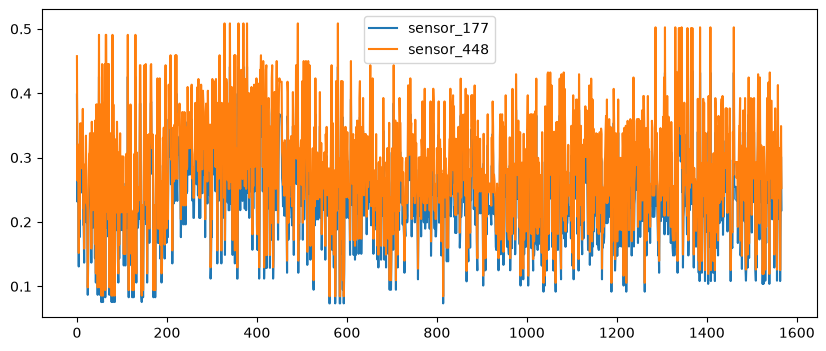

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()

---

## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 값을 "평균에서 표준편차 몇 배 떨어졌나"로 바꿔 적는 것. 단위가 다른 열을 같은 자로 재게 된다 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

In [3]:
# corr() - 두 열이 얼마나 같이 움직이는지 -1 ~ 1 사이 숫자로 계산한다
겹침정도 = df1[센서A].corr(df1[센서B])

print(센서A, "와", 센서B, "의 상관계수:", round(겹침정도, 4))

sensor_177 와 sensor_448 의 상관계수: 0.9999


### 문법 노트 - 열끼리 비교하기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| .corr(다른열) | 두 열의 상관계수를 계산 | 그림 없이 숫자 하나로 겹침 정도를 잰다 |
| .values | 표의 값만 꺼낸다 | 그래프를 그릴 때 줄 번호가 아니라 값만 필요해서 |
| plt.plot() | 값을 순서대로 선으로 잇는다 | 두 센서 모양을 겹쳐 보기 위해 |
| plt.legend() | 어느 선이 무엇인지 표시 | 선이 둘 이상이면 없으면 구분이 안 된다 |

**부호는 무시하고 크기만 본다.**<br>
-0.9 와 0.9 는 방향만 반대일 뿐 "강하게 붙어 다닌다"는 점에서 같다.<br>
그래서 겹치는 짝을 찾을 때는 절댓값을 쓴다.

---

## Step 3. 겹치는 짝 전부 찾아 대표만 남기기

In [4]:
import numpy as np

# df1의 센서 열끼리만 상관계수 행렬 계산
sensor_cols_df1 = [c for c in df1.columns if c.startswith('sensor_')]
corr_matrix = df1[sensor_cols_df1].corr()

cols = corr_matrix.columns.tolist()
corr_values = corr_matrix.values
n = len(cols)

# 위쪽 삼각형만 훑어서 짝을 한 번씩만 골라낸다 (절댓값 0.9 이상)
짝_목록 = []
for i in range(n):
    for j in range(i + 1, n):
        r = corr_values[i, j]
        if not np.isnan(r) and abs(r) >= 0.9:
            짝_목록.append({'센서 A': cols[i], '센서 B': cols[j], '상관계수': round(r, 4)})

짝_df = pd.DataFrame(짝_목록)
짝_df['절댓값'] = 짝_df['상관계수'].abs()
짝_df = 짝_df.sort_values('절댓값', ascending=False).reset_index(drop=True)

print('절댓값 0.9 이상인 짝 수:', len(짝_df))
print('\n상위 10쌍:')
print(짝_df.drop(columns='절댓값').head(10))

절댓값 0.9 이상인 짝 수: 342

상위 10쌍:
         센서 A        센서 B  상관계수
0  sensor_005  sensor_141   1.0
1  sensor_005  sensor_276   1.0
2  sensor_075  sensor_207   1.0
3  sensor_075  sensor_343   1.0
4  sensor_075  sensor_210   1.0
5  sensor_075  sensor_479   1.0
6  sensor_075  sensor_348   1.0
7  sensor_343  sensor_479   1.0
8  sensor_343  sensor_348   1.0
9  sensor_141  sensor_276   1.0


In [5]:
# 빈칸 비율이 적은 열부터 순서대로 살펴본다.
# 빈칸 비율이 같은 열끼리는(동률) 센서 이름 내림차순으로 순서를 정한다 (동률 처리 기준 고정)
빈칸비율_df1 = df1[sensor_cols_df1].isna().mean() * 100
순서_기준 = 빈칸비율_df1.reset_index()
순서_기준.columns = ['센서 이름', '빈칸비율']
순서_기준 = 순서_기준.sort_values(['빈칸비율', '센서 이름'], ascending=[True, False], kind='mergesort')
순서 = 순서_기준['센서 이름'].tolist()

col_to_idx = {c: i for i, c in enumerate(cols)}

남길_센서 = []
남길_idx = []
for c in 순서:
    i = col_to_idx[c]
    겹침 = any(
        not np.isnan(corr_values[i, k]) and abs(corr_values[i, k]) >= 0.9
        for k in 남길_idx
    )
    if not 겹침:
        남길_센서.append(c)
        남길_idx.append(i)

# 센서가 아닌 열(measured_at, result 등)은 그대로 두고, 대표 센서 열만 합친다
비센서_열 = [c for c in df1.columns if c not in sensor_cols_df1]

# df1은 그대로 두고, 중복 제거 결과를 df2라는 새 이름으로 만든다
df2 = df1[비센서_열 + 남길_센서].copy()

print('[정리 전] df1 전체 열 수:', df1.shape[1], '  (그중 센서 열:', len(sensor_cols_df1), '개)')
print('[정리 후] df2 전체 열 수:', df2.shape[1], '  (그중 센서 열:', len(남길_센서), '개)')
print('\n중복으로 제외된 센서 열 수:', len(sensor_cols_df1) - len(남길_센서))
print('\ndf2 행 수, 열 수:', df2.shape)

[정리 전] df1 전체 열 수: 438   (그중 센서 열: 436 개)
[정리 후] df2 전체 열 수: 248   (그중 센서 열: 246 개)

중복으로 제외된 센서 열 수: 190

df2 행 수, 열 수: (1567, 248)


## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [6]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
sensor_578,16.642363,12.485267,4.5820,96.9601
sensor_577,5.563747,16.921369,0.6636,90.4235
sensor_572,2.101836,0.275112,0.9802,2.7395
sensor_571,530.523623,17.499736,317.1964,589.5082
sensor_528,6.395717,1.888698,2.1700,14.4479
sensor_527,1.443457,0.958428,0.1705,8.2037
sensor_525,5.687782,20.663414,1.3104,818.0005
sensor_524,0.453896,4.147581,0.0258,111.3330
sensor_523,14.728866,7.104435,2.6811,137.9838
sensor_522,11.610080,103.122996,0.0000,1000.0000


In [7]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())

평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


값의 크기가 가장 다른 두 열: sensor_022 / sensor_091

sensor_022 - 표준화 전 평균: -5618.3936, 표준편차: 626.8222
sensor_022 - 표준화 후 평균: -0.0, 표준편차: 1.0


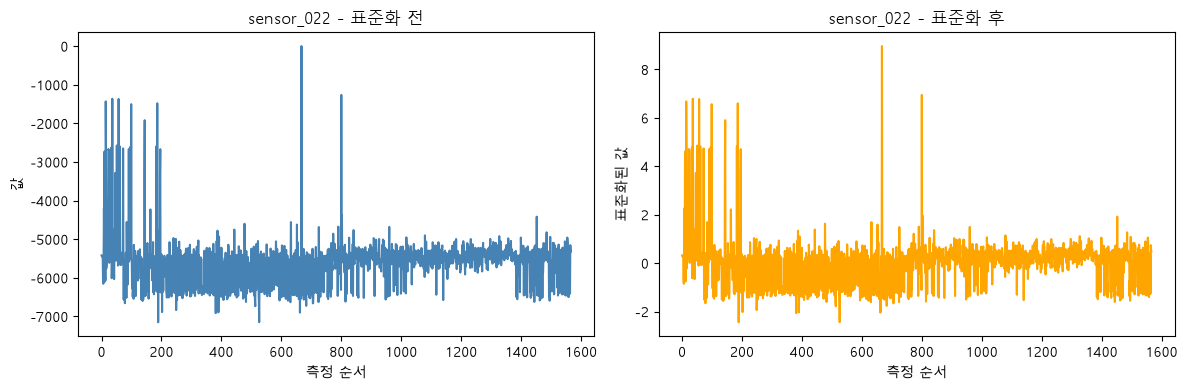


sensor_091 - 표준화 전 평균: 8827.5369, 표준편차: 396.3137
sensor_091 - 표준화 후 평균: -0.0, 표준편차: 1.0


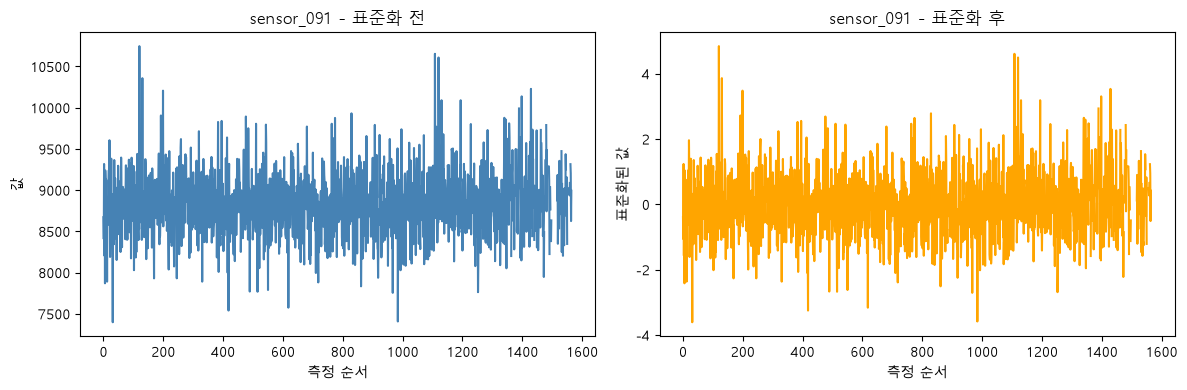

In [8]:
import matplotlib.pyplot as plt

# 한글이 그림에서 깨지지 않도록 폰트를 지정한다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 값의 크기가 가장 다른 두 열: 평균이 가장 작은 센서 / 가장 큰 센서
센서_작은 = 평균들.idxmin()
센서_큰 = 평균들.idxmax()

print("값의 크기가 가장 다른 두 열:", 센서_작은, "/", 센서_큰)

def 표준화(s):
    # (값 - 평균) / 표준편차 → 평균 0, 표준편차 1이 되도록 바꾼다
    # df2 자체는 건드리지 않고, 비교용으로만 새로 계산한다
    return (s - s.mean()) / s.std()

for 센서 in [센서_작은, 센서_큰]:
    원본 = df2[센서]
    표준화값 = 표준화(원본)

    print(f"\n{센서} - 표준화 전 평균: {round(원본.mean(), 4)}, 표준편차: {round(원본.std(), 4)}")
    print(f"{센서} - 표준화 후 평균: {round(표준화값.mean(), 4)}, 표준편차: {round(표준화값.std(), 4)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(원본.values, color="steelblue")
    axes[0].set_title(f"{센서} - 표준화 전")
    axes[0].set_xlabel("측정 순서")
    axes[0].set_ylabel("값")

    axes[1].plot(표준화값.values, color="orange")
    axes[1].set_title(f"{센서} - 표준화 후")
    axes[1].set_xlabel("측정 순서")
    axes[1].set_ylabel("표준화된 값")

    plt.tight_layout()
    plt.show()

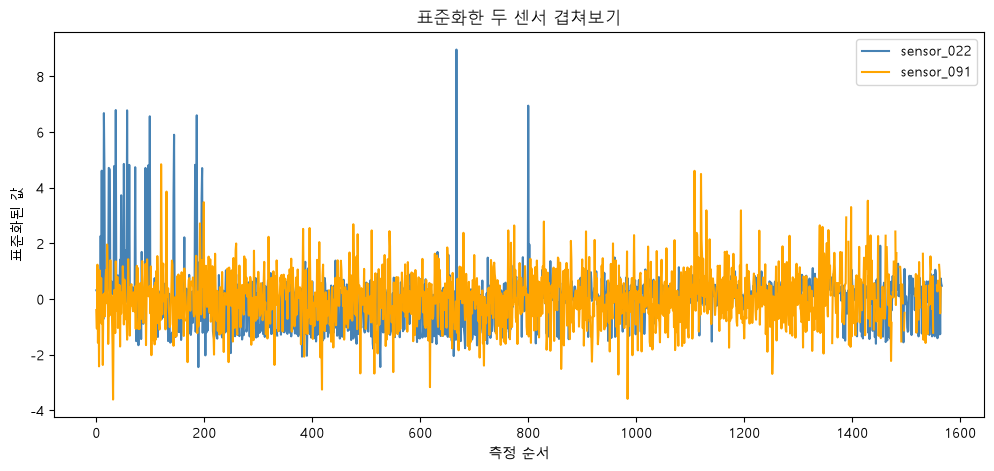

In [9]:
# 표준화한 두 센서를 한 그림에 겹쳐서 그린다 (색으로 구분, 범례로 표시)
표준화_작은 = 표준화(df2[센서_작은])
표준화_큰 = 표준화(df2[센서_큰])

plt.figure(figsize=(12, 5))

plt.plot(표준화_작은.values, color="steelblue", label=센서_작은)
plt.plot(표준화_큰.values, color="orange", label=센서_큰)

plt.title("표준화한 두 센서 겹쳐보기")
plt.xlabel("측정 순서")
plt.ylabel("표준화된 값")
plt.legend()

plt.show()

표준편차가 가장 작은 열: sensor_240 → 0.0014414052325399062
표준편차가 가장 큰 열: sensor_298 → 3226.9242979623277

sensor_240 - 표준화 전 평균: 0.0046, 표준편차: 0.0014
sensor_240 - 표준화 후 평균: 0.0, 표준편차: 1.0


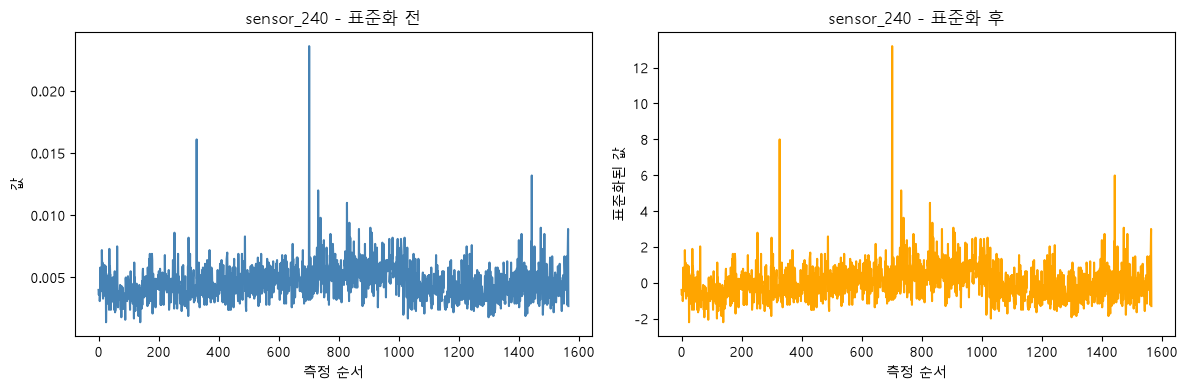


sensor_298 - 표준화 전 평균: 2342.827, 표준편차: 3226.9243
sensor_298 - 표준화 후 평균: 0.0, 표준편차: 1.0


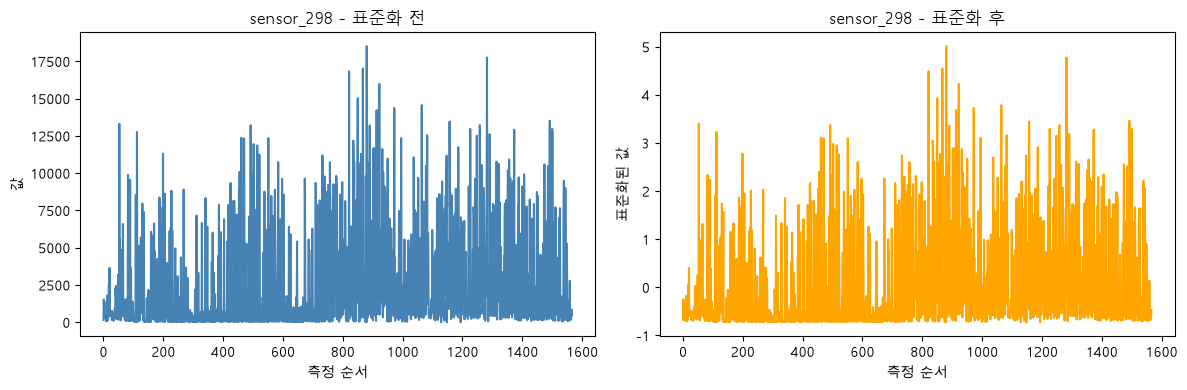

In [10]:
# 센서 열들의 표준편차만 모아서 가장 작은 값과 가장 큰 값을 본다
표준편차들 = df2.describe().T["std"]

센서_표준작은 = 표준편차들.idxmin()
센서_표준큰 = 표준편차들.idxmax()

print("표준편차가 가장 작은 열:", 센서_표준작은, "→", 표준편차들.min())
print("표준편차가 가장 큰 열:", 센서_표준큰, "→", 표준편차들.max())

for 센서 in [센서_표준작은, 센서_표준큰]:
    원본 = df2[센서]
    표준화값 = 표준화(원본)

    print(f"\n{센서} - 표준화 전 평균: {round(원본.mean(), 4)}, 표준편차: {round(원본.std(), 4)}")
    print(f"{센서} - 표준화 후 평균: {round(표준화값.mean(), 4)}, 표준편차: {round(표준화값.std(), 4)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(원본.values, color="steelblue")
    axes[0].set_title(f"{센서} - 표준화 전")
    axes[0].set_xlabel("측정 순서")
    axes[0].set_ylabel("값")

    axes[1].plot(표준화값.values, color="orange")
    axes[1].set_title(f"{센서} - 표준화 후")
    axes[1].set_xlabel("측정 순서")
    axes[1].set_ylabel("표준화된 값")

    plt.tight_layout()
    plt.show()

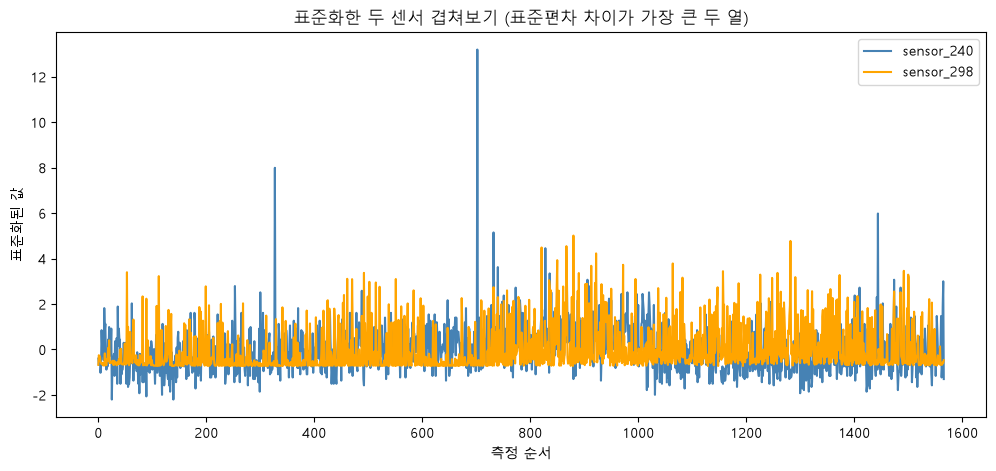

In [11]:
# 표준화한 두 센서(표준편차 기준)를 한 그림에 겹쳐서 그린다 (색으로 구분, 범례로 표시)
표준화_표준작은 = 표준화(df2[센서_표준작은])
표준화_표준큰 = 표준화(df2[센서_표준큰])

plt.figure(figsize=(12, 5))

plt.plot(표준화_표준작은.values, color="steelblue", label=센서_표준작은)
plt.plot(표준화_표준큰.values, color="orange", label=센서_표준큰)

plt.title("표준화한 두 센서 겹쳐보기 (표준편차 차이가 가장 큰 두 열)")
plt.xlabel("측정 순서")
plt.ylabel("표준화된 값")
plt.legend()

plt.show()

표준편차가 가장 큰 열 : sensor_163 → 6553.5693
표준편차가 가장 작은 열: sensor_144 → 0.001282
두 열의 크기 차이     : 5,112,749 배

                   mean          std  min         max
sensor_163  4797.154633  6553.569317  0.0  36871.0000
sensor_144     0.004169     0.001282  0.0      0.0121

[표준화 후] 평균과 표준편차
      sensor_163  sensor_144
mean        -0.0        -0.0
std          1.0         1.0


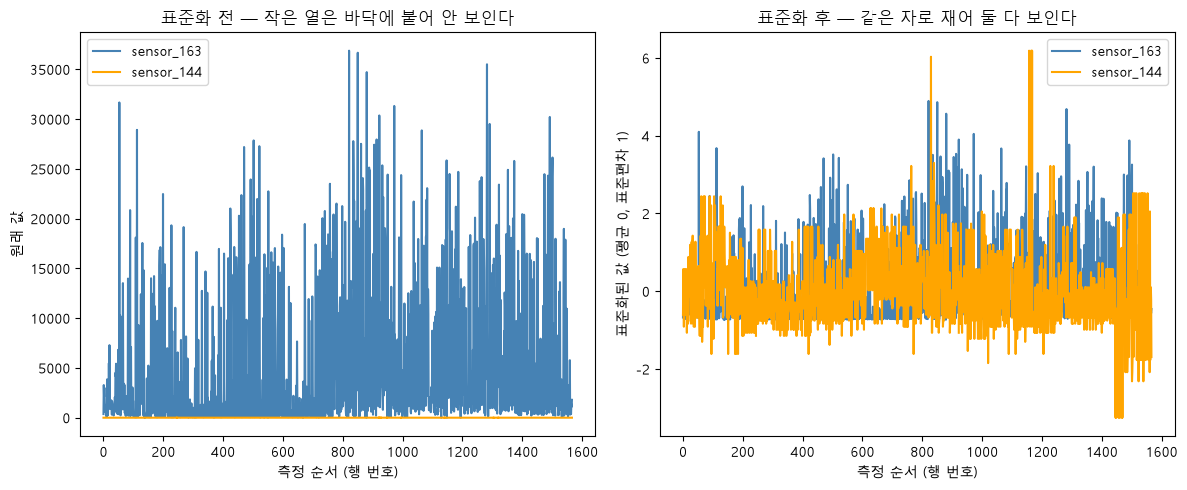


df2는 그대로: (1567, 248)


In [12]:
# sensor_163, sensor_144는 상관계수 중복 제거 과정에서 걸러져 df2에는 없다
# (df1에는 남아 있으므로 df1에서 가져와 비교한다)
센서_163 = "sensor_163"
센서_144 = "sensor_144"

표준편차_비교 = df1[[센서_163, 센서_144]].std()
큰_열 = 표준편차_비교.idxmax()
작은_열 = 표준편차_비교.idxmin()
차이_배 = 표준편차_비교.max() / 표준편차_비교.min()

print(f"표준편차가 가장 큰 열 : {큰_열} → {표준편차_비교.max():.4f}")
print(f"표준편차가 가장 작은 열: {작은_열} → {표준편차_비교.min():.6f}")
print(f"두 열의 크기 차이     : {round(차이_배):,} 배")
print()
print(df1[[센서_163, 센서_144]].describe().T[["mean", "std", "min", "max"]])

표준화_163 = 표준화(df1[센서_163])
표준화_144 = 표준화(df1[센서_144])

표준화_요약 = pd.DataFrame({
    센서_163: [표준화_163.mean(), 표준화_163.std()],
    센서_144: [표준화_144.mean(), 표준화_144.std()],
}, index=["mean", "std"])

print("\n[표준화 후] 평균과 표준편차")
print(표준화_요약.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df1[센서_163].values, label=센서_163, color="steelblue")
axes[0].plot(df1[센서_144].values, label=센서_144, color="orange")
axes[0].set_title("표준화 전 — 작은 열은 바닥에 붙어 안 보인다")
axes[0].set_xlabel("측정 순서 (행 번호)")
axes[0].set_ylabel("원래 값")
axes[0].legend()

axes[1].plot(표준화_163.values, label=센서_163, color="steelblue")
axes[1].plot(표준화_144.values, label=센서_144, color="orange")
axes[1].set_title("표준화 후 — 같은 자로 재어 둘 다 보인다")
axes[1].set_xlabel("측정 순서 (행 번호)")
axes[1].set_ylabel("표준화된 값 (평균 0, 표준편차 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\ndf2는 그대로: {df2.shape}")

## Step 5. 결과와 관련 있는 열부터 순서대로 보기

In [13]:
# 검사 결과를 숫자로 바꾼 새 열 만들기: 불량 → 1, 양품 → 0 (원래 result 열은 그대로 둔다)
df2["불량여부"] = (df2["result"] == "불량").astype(int)

print(df2[["result", "불량여부"]].head())
print()
print("불량여부 값 개수:")
print(df2["불량여부"].value_counts())

# df2의 센서 열 각각에 대해 불량여부와의 상관계수 계산
sensor_cols_df2 = [c for c in df2.columns if c.startswith("sensor_")]
상관계수_시리즈 = df2[sensor_cols_df2].corrwith(df2["불량여부"])

rank_table = pd.DataFrame({
    "센서 이름": 상관계수_시리즈.index,
    "상관계수 절댓값": 상관계수_시리즈.abs().values,
})
rank_table = rank_table.sort_values("상관계수 절댓값", ascending=False).reset_index(drop=True).head(20)

print("\nrank_table (상위 20개):")
rank_table

  result  불량여부
0     양품     0
1     양품     0
2     불량     1
3     양품     0
4     양품     0

불량여부 값 개수:
불량여부
0    1463
1     104
Name: count, dtype: int64

rank_table (상위 20개):


,센서 이름,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_349,0.130180
4,sensor_022,0.108488
5,sensor_029,0.107252
6,sensor_437,0.106910
7,sensor_130,0.103373
8,sensor_125,0.093994
9,sensor_296,0.092249


In [14]:
# rank_table 1등 열 확인
일등_센서 = rank_table.iloc[0]["센서 이름"]
print("rank_table 1등 열:", 일등_센서)

# 검사 결과(양품/불량)별로 그 열의 평균값을 각각 계산
결과별_평균 = df2.groupby("result")[일등_센서].mean()

print(f"\n{일등_센서}의 검사 결과별 평균값:")
print(결과별_평균)

rank_table 1등 열: sensor_060

sensor_060의 검사 결과별 평균값:
result
불량    8.515123
양품    2.563464
Name: sensor_060, dtype: float64


## Step 6. 정제본 저장하고 숫자 검산하기

In [15]:
import os

# rank_table과 같은 기준(불량여부와의 상관계수 절댓값)으로 상위 50개 센서 열을 다시 뽑는다
상위50_센서 = 상관계수_시리즈.abs().sort_values(ascending=False).head(50).index.tolist()

# 상위 50개 센서 열 + result 열만 남긴 표를 df3라는 새 이름으로 만든다
df3 = df2[상위50_센서 + ["result"]].copy()

# 이번 실습 폴더의 results 폴더 안에 저장
os.makedirs("results", exist_ok=True)
저장_경로 = os.path.join("results", "secom_clean.csv")
df3.to_csv(저장_경로, index=False)
print("저장 위치:", os.path.abspath(저장_경로))

# 1. df3 행 수, 열 수
print("\ndf3 행 수, 열 수:", df3.shape)

# 2. df3 안에서 불량 비율
df3_불량비율 = (df3["result"] == "불량").mean() * 100
print(f"df3 안 불량 비율: {round(df3_불량비율, 2)}%")

# 3. 원본 df에서 불량 비율
df_불량비율 = (df["result"] == "불량").mean() * 100
print(f"원본 df 불량 비율: {round(df_불량비율, 2)}%")

저장 위치: C:\Users\subin\OneDrive\바탕 화면\secome-project\day02\lab06_clean-dataset\results\secom_clean.csv

df3 행 수, 열 수: (1567, 51)
df3 안 불량 비율: 6.64%
원본 df 불량 비율: 6.64%


## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 / 검사 결과 포함 | [436/438] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 / 검사 결과 포함 | [248/249] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

---
## 직접 해보기 (도전) - 기준을 바꿔 두 번째 정제본 만들기

- 상황: 상위 50개로 잘랐는데, 20개로 자르면 무엇이 달라지는지 아직 모른다
- 할 일: 개수 기준만 바꿔 두 번째 정제본을 만들고 숫자를 비교한다
- 결과물: 정제본 파일 1개 추가 + 세 줄짜리 비교표 1개

In [16]:
# rank_table과 같은 기준(불량여부와의 상관계수 절댓값)으로 상위 20개 센서 열 뽑기
상위20_센서 = 상관계수_시리즈.abs().sort_values(ascending=False).head(20).index.tolist()

# 정제본 B: 상위 20개 센서 열 + result 열만 남긴 표를 df3b라는 새 이름으로 만든다
df3b = df2[상위20_센서 + ["result"]].copy()

# results 폴더에 저장 (기존 df3, secom_clean.csv는 건드리지 않는다)
저장_경로_B = os.path.join("results", "secom_clean_b.csv")
df3b.to_csv(저장_경로_B, index=False)
print("저장 위치:", os.path.abspath(저장_경로_B))

# A(상위 50)와 B(상위 20) 비교
공통_센서 = set(상위50_센서) & set(상위20_센서)

관련도_A_최소 = 상관계수_시리즈.abs()[상위50_센서].min()
관련도_B_최소 = 상관계수_시리즈.abs()[상위20_센서].min()

비교표 = pd.DataFrame({
    "정제본": ["A (상위 50)", "B (상위 20)"],
    "열 수": [df3.shape[1], df3b.shape[1]],
    "공통 센서 열 개수": [len(공통_센서), len(공통_센서)],
    "관련도 최솟값": [round(관련도_A_최소, 6), round(관련도_B_최소, 6)],
})
비교표

저장 위치: C:\Users\subin\OneDrive\바탕 화면\secome-project\day02\lab06_clean-dataset\results\secom_clean_b.csv


,정제본,열 수,공통 센서 열 개수,관련도 최솟값
0,A (상위 50),51,20,0.052085
1,B (상위 20),21,20,0.076563


### 정제본 A vs B

| 항목 | A (상위 50) | B (상위 20) |
|---|---|---|
| 열 수 | [50] | [20] |
| 공통으로 들어간 열 수 | [20] | [20] |
| 관련도 최솟값 | [0.052] | [0.077] |